In [49]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error, r2_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import requests
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning, message='invalid value encountered in log')
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [50]:
# Importing the list of S&P 500 companies from Wikipedia
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"}

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
response = requests.get(url, headers=headers)
response.raise_for_status()

table = pd.read_html(response.text)
df = table[0]
tickers = df['Symbol'].to_list()

print(f"Found {len(tickers)} tickers")
print(tickers[:10])

Found 503 tickers
['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']


In [51]:
# Download all S&P 500 stocks for 2025
data = yf.download(tickers, start="2025-01-01", end="2025-12-31", auto_adjust=True)
print(data.shape)
print(data.head())
tickers_fixed = [t.replace('.', '-') for t in tickers]
data = yf.download(tickers_fixed, start="2025-01-01", end="2025-12-31", auto_adjust=True)

[*********************100%***********************]  503 of 503 completed

2 Failed downloads:
['BF.B']: YFPricesMissingError('possibly delisted; no price data found  (1d 2025-01-01 -> 2025-12-31)')
['BRK.B']: YFTzMissingError('possibly delisted; no timezone found')
[                       1%                       ]  5 of 503 completed

(249, 2517)
Price      Adj Close             Close                                      \
Ticker          BF.B BRK.B           A        AAPL        ABBV        ABNB   
Date                                                                         
2025-01-02       NaN   NaN  132.063141  242.525177  170.578766  131.479996   
2025-01-03       NaN   NaN  134.299973  242.037827  172.270844  135.710007   
2025-01-06       NaN   NaN  135.032394  243.668915  171.206192  135.199997   
2025-01-07       NaN   NaN  136.002350  240.894073  170.664322  131.289993   
2025-01-08       NaN   NaN  135.596558  241.381393  169.685181  130.800003   

Price                                                      ...   Volume  \
Ticker             ABT       ACGL         ACN        ADBE  ...       WY   
Date                                                       ...            
2025-01-02  110.078766  91.379997  341.018036  441.000000  ...  3446800   
2025-01-03  110.457222  91.400002  345.935486  430.570007  ... 

[*********************100%***********************]  503 of 503 completed


In [52]:
# Extract closing prices
closes = data['Close']

# Log returns
log_returns = np.log(closes / closes.shift(1))

# Volatility of log returns (20-day rolling standard deviation annualized)
volatility = log_returns.rolling(20).std() * np.sqrt(252)


In [53]:
tech = df[df['GICS Sector'] == 'Information Technology']['Symbol'].tolist()
banks = df[df['GICS Sector'] == 'Financials']['Symbol'].tolist()
health_care = df[df['GICS Sector'] == 'Health Care']['Symbol'].tolist()
utilities = df[df['GICS Sector'] == 'Utilities']['Symbol'].tolist()

# Filter to only tickers that exist in the volatility dataframe
tech = [t for t in tech if t in volatility.columns]
banks = [t for t in banks if t in volatility.columns]
health_care = [t for t in health_care if t in volatility.columns]
utilities = [t for t in utilities if t in volatility.columns]

print(f"Tech: {len(tech)}")
print(f"Banks: {len(banks)}")
print(f"Health Care: {len(health_care)}")
print(f"Utilities: {len(utilities)}")

Tech: 73
Banks: 75
Health Care: 58
Utilities: 31


In [ ]:
# creating the features for this model
def build_features(log_ret, vol):
    vol = vol.dropna()
    log_ret = log_ret.loc[vol.index]
    
    features = pd.DataFrame(index=vol.index)
    features['volatility_5']  = vol.rolling(5).mean().shift(1)   # lag everything by 1
    features['volatility_20'] = vol.rolling(20).mean().shift(1)  # so no future info leaks
    features['volatility_60'] = vol.rolling(60).mean().shift(1)
    features['lag_1']         = log_ret.shift(1)
    features['lag_5']         = log_ret.shift(5)
    features['rolling_mean']  = log_ret.rolling(20).mean().shift(1)
    features['target']        = vol.shift(- 20)
    return features.dropna()

## Data Validation

Before running analysis, I checked if the log returns were normally distributed using the Shapiro-Wilk and Jarque-Bera along with visual inspections via histograms and QQ plots.

We can see that the log returns’ normality is dependent on the sector for the stocks. I found that for Tech, Health Care, and Financials rougly 40~45% of those stocks failed the normality test. Compared to Utilities, where 13% of the stocks failed the normality test. This motivated a Student likelihood test for the Metropolis-Hastening method to handle the fat-tailed data.


Sector:Information Technology
Ticker: ACN - Shapiro-Wilk p-value: 0.0000, Jarque-Bera p-value: 0.0000
Ticker: ADBE - Shapiro-Wilk p-value: 0.0000, Jarque-Bera p-value: 0.0000
Ticker: AMD - Shapiro-Wilk p-value: 0.0000, Jarque-Bera p-value: 0.0000
Sector:Financials
Ticker: AFL - Shapiro-Wilk p-value: 0.0000, Jarque-Bera p-value: 0.0000
Ticker: ALL - Shapiro-Wilk p-value: 0.0000, Jarque-Bera p-value: 0.0000
Ticker: AXP - Shapiro-Wilk p-value: 0.0000, Jarque-Bera p-value: 0.0000
Sector:Health Care
Ticker: ABT - Shapiro-Wilk p-value: 0.0000, Jarque-Bera p-value: 0.0000
Ticker: ABBV - Shapiro-Wilk p-value: 0.0000, Jarque-Bera p-value: 0.0000
Ticker: A - Shapiro-Wilk p-value: 0.0000, Jarque-Bera p-value: 0.0000
Sector:Utilities
Ticker: AES - Shapiro-Wilk p-value: 0.0000, Jarque-Bera p-value: 0.0000
Ticker: LNT - Shapiro-Wilk p-value: 0.0000, Jarque-Bera p-value: 0.0000
Ticker: AEE - Shapiro-Wilk p-value: 0.0000, Jarque-Bera p-value: 0.0000


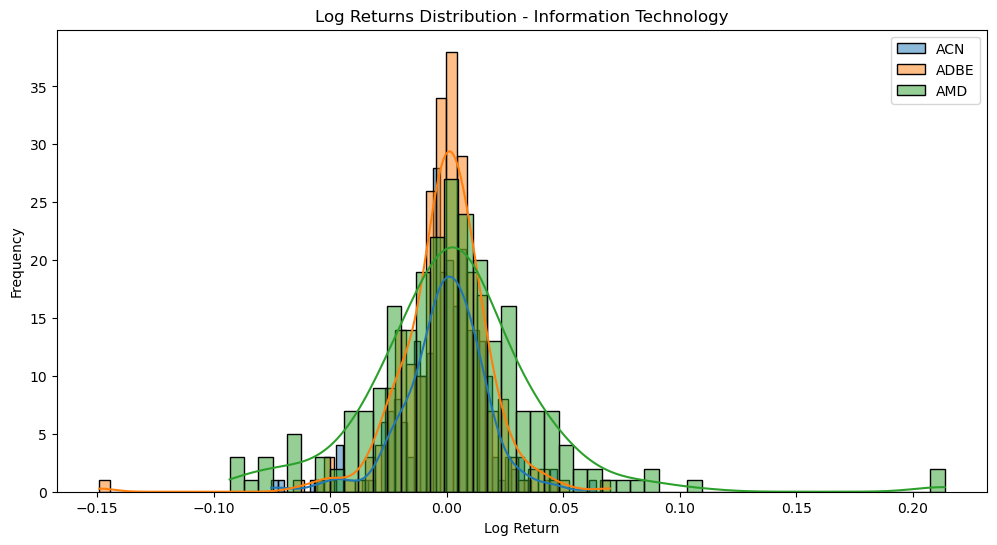

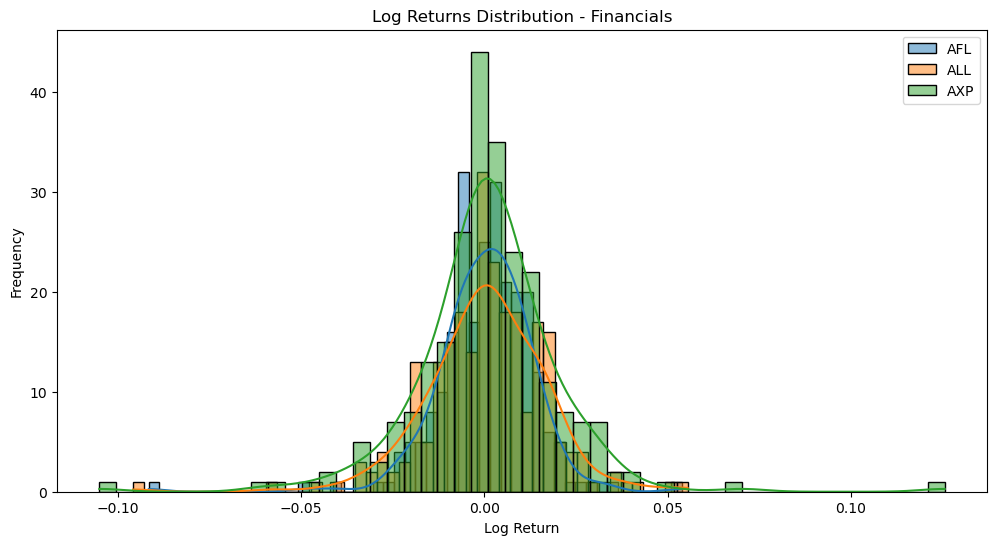

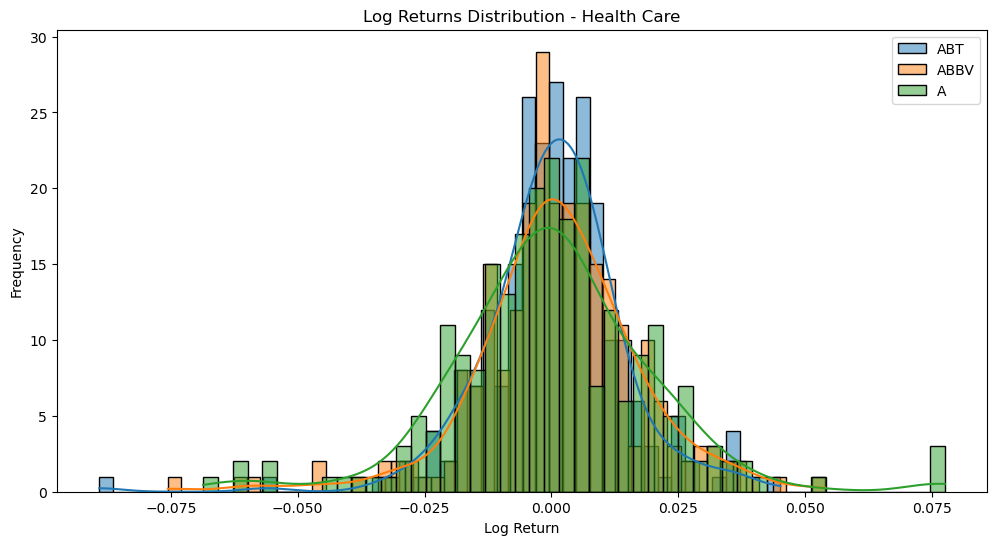

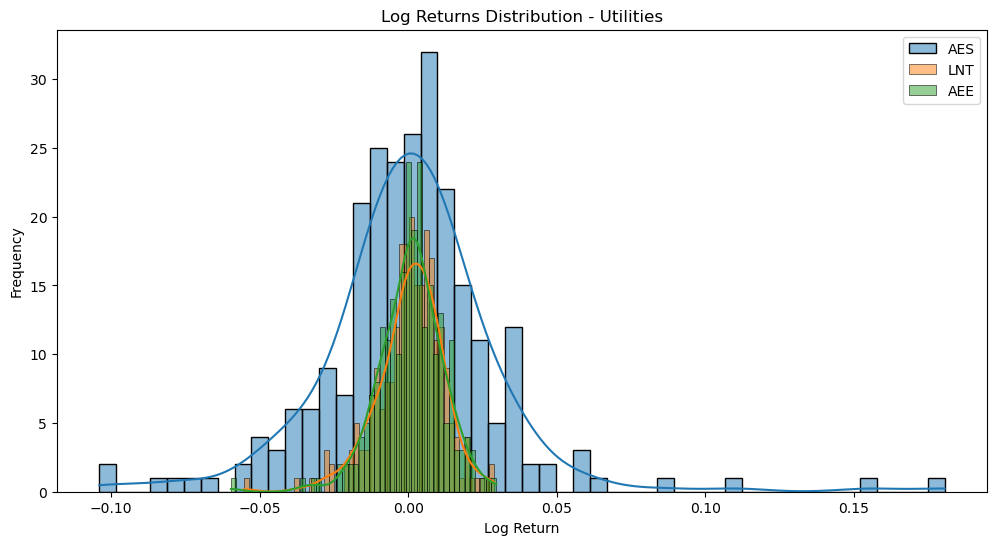

In [55]:
# testing for normality of the log returns using the Shapiro-Wilk test and Jarque-Bera test
from scipy.stats import shapiro,jarque_bera

target_sectors = {
    'Information Technology': tech,
    'Financials': banks,
    'Health Care' : health_care,
    'Utilities': utilities
}

for sector_name, tickers in target_sectors.items():
    print(f'Sector:{sector_name}')
    for t in tickers[:3]:
        returns = log_returns[t].dropna()
        sw_stat, sw_p = shapiro(returns)
        jb_stat, jb_p = jarque_bera(returns)
        print(f'Ticker: {t} - Shapiro-Wilk p-value: {sw_p:.4f}, Jarque-Bera p-value: {jb_p:.4f}')

# plotting the distribution of log returns for a few stocks in each sector
for sector_name, tickers in target_sectors.items():
    plt.figure(figsize=(12, 6))
    for t in tickers[:3]:
        sns.histplot(log_returns[t].dropna(), kde=True, label=t, bins=50)
    plt.title(f'Log Returns Distribution - {sector_name}')
    plt.xlabel('Log Return')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()
    



## Machine Learning Section

In [56]:
# Build features for each sector
sector_features = {
    sector_name: pd.concat(
        [build_features(log_returns[t], volatility[t]) for t in tickers],
        keys=tickers
    ).dropna()
    for sector_name, tickers in target_sectors.items()
}

# Check shape of each sector
for sector_name, features in sector_features.items():
    print(f"{sector_name}: {features.shape}")
    
for sector_name, features in sector_features.items():
    print(f"{sector_name}: {features.shape}")
    

Information Technology: (10700, 7)
Financials: (11154, 7)
Health Care: (8642, 7)
Utilities: (4619, 7)
Information Technology: (10700, 7)
Financials: (11154, 7)
Health Care: (8642, 7)
Utilities: (4619, 7)


## Training Random Forest Regressor

Random Forest struggled to predict volatility out-of-sample, particularly in Health Care ($\R^2$ = -0.03). This could be due to unpredictable events like FDA approvals, which introduce unpredictable randomness. Financials showed the best predictors($\R^2$ = 0.52), this could be due to exposure to interest rate movement. 


In [57]:
rf_results = {}

def train_test_split_ts(df, split=0.8):
    dates = df.index.get_level_values('Date').unique().sort_values()
    split_idx = int(len(dates) * split)
    split_date = dates[split_idx]
    train = df[df.index.get_level_values('Date') < split_date]
    test = df[df.index.get_level_values('Date') >= split_date]
    return train, test

def get_X_y(df):
    return df.drop('target', axis=1), df['target']

for sector_name, features in sector_features.items():
    train, test = train_test_split_ts(features)
    X_train, y_train = get_X_y(train)
    X_test, y_test = get_X_y(test)
    
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    rf_results[sector_name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'model': rf}
    print(f"{sector_name} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")

Information Technology | RMSE: 0.1762 | MAE: 0.1243 | R2: 0.3166
Financials | RMSE: 0.0767 | MAE: 0.0558 | R2: 0.5136
Health Care | RMSE: 0.1190 | MAE: 0.0795 | R2: -0.0289
Utilities | RMSE: 0.0755 | MAE: 0.0474 | R2: 0.4371


## MLP

Random Forest outperformed the MLP on high volatility sectors (Tech and Financials). MLP showed a significant advantage on Utilities ($\R^2$ = 0.74 vs 0.44). This could suggest neural networks could be better at capturing the smooth, regular volatility patterns of heavily regulated industries, while ensemble tree methods are more robust to the noisy, event-driven volatility fo Tech and Financials

In [58]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [59]:
# Convert sector features to tensors
def prepare_tensors(df):
    X, y = get_X_y(df)
    X_tensor = torch.tensor(X.values, dtype=torch.float32)
    y_tensor = torch.tensor(y.values, dtype=torch.float32).unsqueeze(1)
    return X_tensor, y_tensor

# Define the MLP
class VolatilityMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

# Train and evaluate
mlp_results = {}

for sector_name, features in sector_features.items():
    train, test = train_test_split_ts(features)
    
    X_train, y_train = prepare_tensors(train)
    X_test, y_test = prepare_tensors(test)
    
    dataset = TensorDataset(X_train, y_train)
    loader = DataLoader(dataset, batch_size=32, shuffle=False)
    
    model = VolatilityMLP(input_dim=X_train.shape[1])
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    
    # Training loop
    model.train()
    for epoch in range(100):
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
    
    # Evaluation
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test).squeeze().numpy()
        y_true = y_test.squeeze().numpy()
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    mlp_results[sector_name] = {'RMSE': rmse,'MAE': mae, 'R2': r2}
    print(f"{sector_name} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")

Information Technology | RMSE: 0.1545 | MAE: 0.1070 | R2: 0.4746
Financials | RMSE: 0.0737 | MAE: 0.0517 | R2: 0.5512
Health Care | RMSE: 0.1062 | MAE: 0.0676 | R2: 0.1813
Utilities | RMSE: 0.0681 | MAE: 0.0382 | R2: 0.5416


## Metropolis Hasting



In [60]:
def log_likelihood(sigma, returns):
    n = len(returns)
    return -n * np.log(sigma) - 0.5 * np.sum((returns / sigma) ** 2)

def log_prior(sigma):
    # Half-normal prior on volatility - must be positive
    if sigma <= 0:
        return -np.inf
    return -0.5 * (sigma / 0.5) ** 2  # scale of 0.5 is reasonable for daily vol

def log_posterior(sigma, returns):
    return log_likelihood(sigma, returns) + log_prior(sigma)

def metropolis_hastings(returns, n_samples=10000, step_size=0.01, burn_in=2000):
    samples = []
    sigma_current = np.std(returns)  # initialize at sample std
    
    for i in range(n_samples + burn_in):
        # Propose new sigma using random walk (same idea as the Ising sweep)
        sigma_proposed = sigma_current + np.random.normal(0, step_size)
        
        # Acceptance ratio (log scale for numerical stability)
        log_accept = log_posterior(sigma_proposed, returns) - log_posterior(sigma_current, returns)
        
        # Accept or reject
        if np.log(np.random.uniform()) < log_accept:
            sigma_current = sigma_proposed
        
        if i >= burn_in:  # discard burn-in samples
            samples.append(sigma_current)
    
    return np.array(samples)

In [61]:
mh_results = {}

for sector_name, tickers in target_sectors.items():
    sector_sigmas = []
    
    for t in tickers:
        returns = log_returns[t].dropna().values
        samples = metropolis_hastings(returns, n_samples=5000, burn_in=1000)
        
        sector_sigmas.append({
            'ticker': t,
            'mean': np.mean(samples),
            'std': np.std(samples),
            'lower': np.percentile(samples, 2.5),   # 95% credible interval
            'upper': np.percentile(samples, 97.5)
        })
    
    mh_results[sector_name] = sector_sigmas
    print(f"{sector_name} done — {len(sector_sigmas)} stocks sampled")

Information Technology done — 73 stocks sampled
Financials done — 75 stocks sampled
Health Care done — 58 stocks sampled
Utilities done — 31 stocks sampled


In [62]:
for sector_name, stocks in mh_results.items():
    means = [s['mean'] for s in stocks]
    print(f"\n{sector_name}")
    print(f"  Avg posterior volatility: {np.mean(means):.4f}")
    print(f"  Min: {min(means):.4f} | Max: {max(means):.4f}")


Information Technology
  Avg posterior volatility: 0.0284
  Min: 0.0134 | Max: 0.0610

Financials
  Avg posterior volatility: 0.0193
  Min: 0.0119 | Max: 0.0477

Health Care
  Avg posterior volatility: 0.0220
  Min: 0.0126 | Max: 0.0431

Utilities
  Avg posterior volatility: 0.0164
  Min: 0.0105 | Max: 0.0430


## ARIMA-GARCH
 

In [63]:
from statsmodels.tsa.stattools import adfuller

adf_results = {
    sector_name: [
        (t, adfuller(volatility[t].dropna()))
        for t in tickers
    ]
    for sector_name, tickers in target_sectors.items()
}

# Summarize how many are stationary per sector
for sector_name, results in adf_results.items():
    stationary = sum(1 for _, (stat, p, *_) in results if p < 0.05)
    total = len(results)
    print(f"{sector_name}: {stationary}/{total} stationary")

Information Technology: 11/73 stationary
Financials: 6/75 stationary
Health Care: 9/58 stationary
Utilities: 7/31 stationary


In [64]:
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
import warnings
warnings.filterwarnings('ignore')
arima_garch_results = {}

for sector_name, tickers in target_sectors.items():
    sector_preds = []
    sector_actuals = []
    
    for t in tickers:
        try:
            vol_series = volatility[t].dropna()
            
            # Train/test split on the raw series
            split_idx = int(len(vol_series) * 0.8)
            train_vol = vol_series.iloc[:split_idx]
            test_vol = vol_series.iloc[split_idx:]
            
            # Fit ARIMA(1,1,1) on train
            arima = ARIMA(train_vol, order=(1,1,1)).fit()
            
            # Get ARIMA residuals for GARCH — rescale by 100 to fix scaling issue
            residuals = arima.resid * 100
            
            # Fit GARCH(1,1) on rescaled residuals
            garch = arch_model(residuals, vol='Garch', p=1, q=1).fit(disp='off', show_warning=False)
            
            # Forecast
            arima_forecast = arima.forecast(steps=len(test_vol))
            
            sector_preds.extend(arima_forecast.values)
            sector_actuals.extend(test_vol.values)
            
        except Exception as e:
            continue
    
    sector_preds = np.array(sector_preds)
    sector_actuals = np.array(sector_actuals)
    
    rmse = np.sqrt(mean_squared_error(sector_actuals, sector_preds))
    mae = mean_absolute_error(sector_actuals, sector_preds)
    r2 = r2_score(sector_actuals, sector_preds)
    
    arima_garch_results[sector_name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
    print(f"{sector_name} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")

Information Technology | RMSE: 0.1450 | MAE: 0.0989 | R2: 0.5042
Financials | RMSE: 0.1316 | MAE: 0.0683 | R2: 0.2082
Health Care | RMSE: 0.1366 | MAE: 0.0970 | R2: -0.1391
Utilities | RMSE: 0.0916 | MAE: 0.0444 | R2: 0.2531


## Testing For Statistical significance


In [65]:
mlp_results = {}

for sector_name, features in sector_features.items():
    train, test = train_test_split_ts(features)
    
    X_train, y_train = prepare_tensors(train)
    X_test, y_test = prepare_tensors(test)
    
    dataset = TensorDataset(X_train, y_train)
    loader = DataLoader(dataset, batch_size=32, shuffle=False)
    
    model = VolatilityMLP(input_dim=X_train.shape[1])
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    
    model.train()
    for epoch in range(100):
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
    
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test).squeeze().numpy()
        y_true = y_test.squeeze().numpy()
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    mlp_results[sector_name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'model': model}
    print(f"{sector_name} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")

Information Technology | RMSE: 0.1585 | MAE: 0.1072 | R2: 0.4473
Financials | RMSE: 0.0820 | MAE: 0.0561 | R2: 0.4439
Health Care | RMSE: 0.1085 | MAE: 0.0695 | R2: 0.1441
Utilities | RMSE: 0.0673 | MAE: 0.0376 | R2: 0.5529


In [66]:
from scipy.stats import ttest_rel, wilcoxon
import warnings
warnings.filterwarnings('ignore')

sig_results = {}

for sector_name, features in sector_features.items():
    train, test = train_test_split_ts(features)
    X_test, y_test = get_X_y(test)
    y_true = y_test.values

    # RF predictions
    rf_preds = rf_results[sector_name]['model'].predict(X_test)

    # MLP predictions
    X_tensor = torch.tensor(X_test.values, dtype=torch.float32)
    mlp_model = mlp_results[sector_name]['model']
    mlp_model.eval()
    with torch.no_grad():
        mlp_preds = mlp_model(X_tensor).squeeze().numpy()

    # ARIMA-GARCH predictions — rerun forecast to get aligned predictions
    ag_preds = []
    ag_actuals = []
    for t in target_sectors[sector_name]:
        try:
            vol_series = volatility[t].dropna()
            split_idx = int(len(vol_series) * 0.8)
            train_vol = vol_series.iloc[:split_idx]
            test_vol = vol_series.iloc[split_idx:]
            arima = ARIMA(train_vol, order=(1,1,1)).fit()
            forecast = arima.forecast(steps=len(test_vol))
            ag_preds.extend(forecast.values)
            ag_actuals.extend(test_vol.values)
        except:
            continue
    ag_preds = np.array(ag_preds)
    ag_actuals = np.array(ag_actuals)

    # Squared errors for RF and MLP (same length)
    rf_errors  = (y_true - rf_preds) ** 2
    mlp_errors = (y_true - mlp_preds) ** 2

    # Squared errors for ARIMA-GARCH (different length due to per-stock split)
    ag_errors  = (ag_actuals - ag_preds) ** 2

    # Trim to shortest length for cross-model comparison
    min_len = min(len(rf_errors), len(mlp_errors), len(ag_errors))
    rf_errors  = rf_errors[:min_len]
    mlp_errors = mlp_errors[:min_len]
    ag_errors  = ag_errors[:min_len]

    # Paired t-tests
    rf_vs_mlp   = ttest_rel(rf_errors, mlp_errors)
    rf_vs_ag    = ttest_rel(rf_errors, ag_errors)
    mlp_vs_ag   = ttest_rel(mlp_errors, ag_errors)

    # Wilcoxon signed-rank test (non-parametric alternative given non-normality)
    rf_vs_mlp_w  = wilcoxon(rf_errors, mlp_errors)
    rf_vs_ag_w   = wilcoxon(rf_errors, ag_errors)
    mlp_vs_ag_w  = wilcoxon(mlp_errors, ag_errors)

    sig_results[sector_name] = {
        'RF vs MLP':        {'t-test p': rf_vs_mlp.pvalue,   'wilcoxon p': rf_vs_mlp_w.pvalue},
        'RF vs ARIMA-GARCH': {'t-test p': rf_vs_ag.pvalue,    'wilcoxon p': rf_vs_ag_w.pvalue},
        'MLP vs ARIMA-GARCH':{'t-test p': mlp_vs_ag.pvalue,   'wilcoxon p': mlp_vs_ag_w.pvalue},
    }

# Print results
for sector_name, comparisons in sig_results.items():
    print(f"\n========= {sector_name} =========")
    for comparison, pvals in comparisons.items():
        t_sig = 'Yes' if pvals['t-test p'] < 0.05 else 'No'
        w_sig = 'Yes' if pvals['wilcoxon p'] < 0.05 else 'No'
        print(f"  {comparison}")
        print(f"    t-test p={pvals['t-test p']:.4f} (Sig: {t_sig}) | Wilcoxon p={pvals['wilcoxon p']:.4f} (Sig: {w_sig})")


========= Information Technology =========
  RF vs MLP
    t-test p=0.0000 (Sig: Yes) | Wilcoxon p=0.0000 (Sig: Yes)
  RF vs ARIMA-GARCH
    t-test p=0.0023 (Sig: Yes) | Wilcoxon p=0.0000 (Sig: Yes)
  MLP vs ARIMA-GARCH
    t-test p=0.8274 (Sig: No) | Wilcoxon p=0.2926 (Sig: No)

========= Financials =========
  RF vs MLP
    t-test p=0.0002 (Sig: Yes) | Wilcoxon p=0.3704 (Sig: No)
  RF vs ARIMA-GARCH
    t-test p=0.0011 (Sig: Yes) | Wilcoxon p=0.0000 (Sig: Yes)
  MLP vs ARIMA-GARCH
    t-test p=0.0020 (Sig: Yes) | Wilcoxon p=0.0000 (Sig: Yes)

========= Health Care =========
  RF vs MLP
    t-test p=0.0000 (Sig: Yes) | Wilcoxon p=0.0000 (Sig: Yes)
  RF vs ARIMA-GARCH
    t-test p=0.0002 (Sig: Yes) | Wilcoxon p=0.0000 (Sig: Yes)
  MLP vs ARIMA-GARCH
    t-test p=0.0000 (Sig: Yes) | Wilcoxon p=0.0000 (Sig: Yes)

========= Utilities =========
  RF vs MLP
    t-test p=0.0000 (Sig: Yes) | Wilcoxon p=0.0000 (Sig: Yes)
  RF vs ARIMA-GARCH
    t-test p=0.0000 (Sig: Yes) | Wilcoxon p=0.0000 (

## Visualization for comparing these models

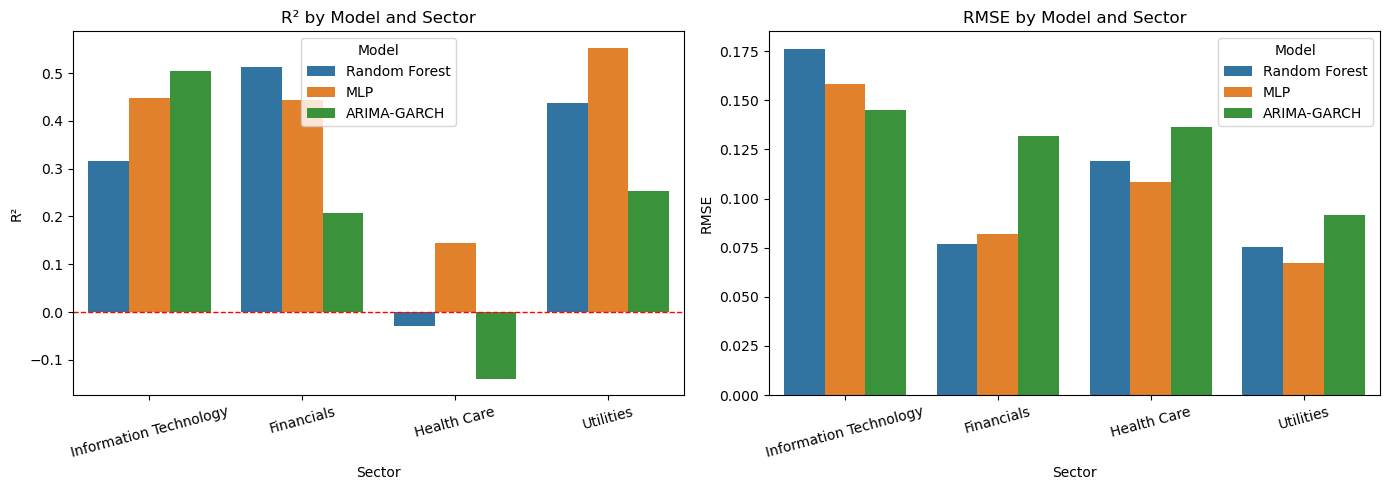

In [67]:

comparison = pd.DataFrame([
    {'Sector': s, 'Model': 'Random Forest', 'R2': rf_results[s]['R2'], 'RMSE': rf_results[s]['RMSE']}
    for s in rf_results
] + [
    {'Sector': s, 'Model': 'MLP', 'R2': mlp_results[s]['R2'], 'RMSE': mlp_results[s]['RMSE']}
    for s in mlp_results
] + [
    {'Sector': s, 'Model': 'ARIMA-GARCH', 'R2': arima_garch_results[s]['R2'], 'RMSE': arima_garch_results[s]['RMSE']}
    for s in arima_garch_results
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² comparison
sns.barplot(data=comparison, x='Sector', y='R2', hue='Model', ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('R² by Model and Sector')
axes[0].set_ylabel('R²')
axes[0].tick_params(axis='x', rotation=15)

# RMSE comparison
sns.barplot(data=comparison, x='Sector', y='RMSE', hue='Model', ax=axes[1])
axes[1].set_title('RMSE by Model and Sector')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

**Metropolis Hastings Visualization**


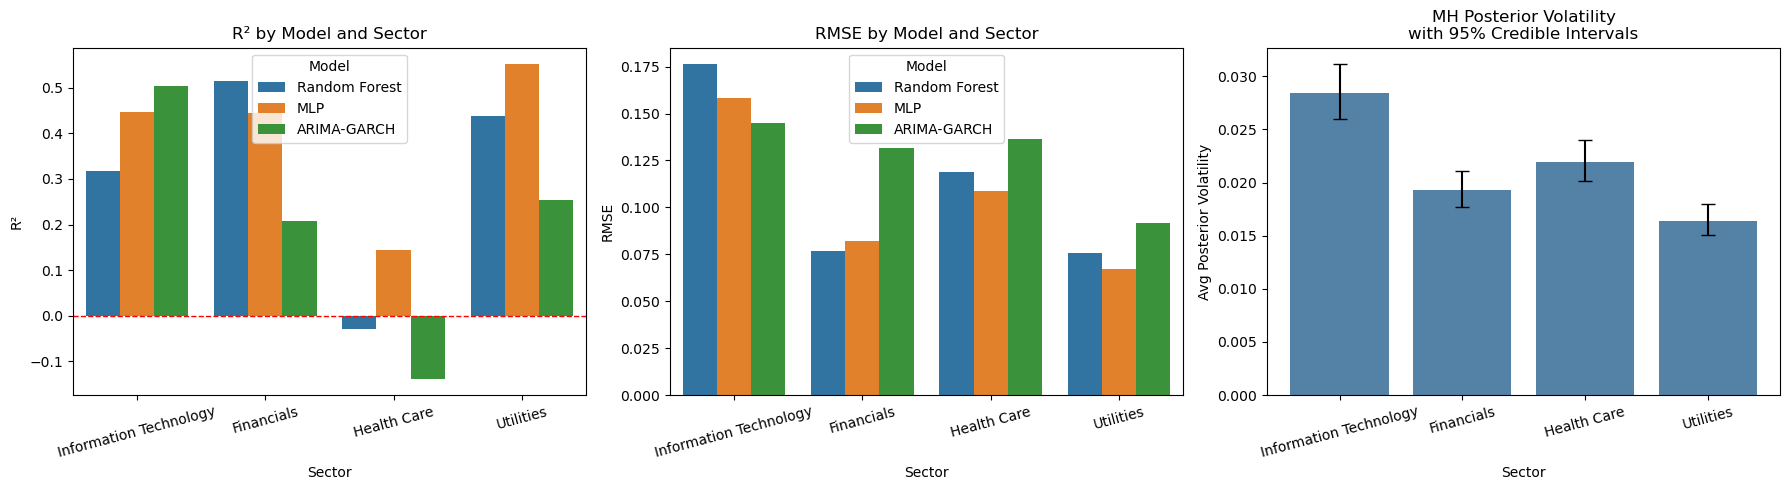

In [68]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# R² comparison
sns.barplot(data=comparison, x='Sector', y='R2', hue='Model', ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('R² by Model and Sector')
axes[0].set_ylabel('R²')
axes[0].tick_params(axis='x', rotation=15)

# RMSE comparison
sns.barplot(data=comparison, x='Sector', y='RMSE', hue='Model', ax=axes[1])
axes[1].set_title('RMSE by Model and Sector')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=15)

# MH posterior volatility with credible intervals
mh_summary = pd.DataFrame([
    {
        'Sector': sector_name,
        'Mean Vol': np.mean([s['mean'] for s in stocks]),
        'Lower': np.mean([s['lower'] for s in stocks]),
        'Upper': np.mean([s['upper'] for s in stocks])
    }
    for sector_name, stocks in mh_results.items()
])

sns.barplot(data=mh_summary, x='Sector', y='Mean Vol', ax=axes[2], color='steelblue')
axes[2].errorbar(
    x=range(len(mh_summary)),
    y=mh_summary['Mean Vol'],
    yerr=[mh_summary['Mean Vol'] - mh_summary['Lower'],
          mh_summary['Upper'] - mh_summary['Mean Vol']],
    fmt='none', color='black', capsize=5
)
axes[2].set_title('MH Posterior Volatility\nwith 95% Credible Intervals')
axes[2].set_ylabel('Avg Posterior Volatility')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()